In [1]:
import sys
sys.path.append('..')

from matplotlib import pyplot as plt
from src.analysis import break_even_analysis, comparative_statics, stochastic_bivariate_simulation, run_monte_carlo, \
    run_two_way_sensitivity_analysis
from src.config import variable_names
from src.engine import evaluate_chained_models, evaluate_variable_scenario_sweep, evaluate_expected_scenario
from src.models import ProfitModel, CostOfGoodsSoldModel, RevenueModel, FreeCashFlowModel, \
    CapitalExpenditureModel, DepreciationModel, TotalExpenseModel, NetIncomeModel, RoiModel, TotalCostModel, \
    AdvertisingEfficiencyModel
from src.variables import Orders, SellingPrice, PurchasingPrice, ItemsPerOrder, USDToRMB, Rent, TaxRate, \
    CostPerAcquisition, ConversionRate, RenderFee, TravelFee, AdvertisingCost, Expense, SetupCost
from src.visualization import generate_linear_regression_from_lists

In [2]:
cogs_model = CostOfGoodsSoldModel()
cost_model = TotalCostModel()
revenue_model = RevenueModel()
expense_model = TotalExpenseModel()
depreciation_model = DepreciationModel()
capital_expenditure_model = CapitalExpenditureModel()
net_income_model = NetIncomeModel()
advertising_efficiency_model = AdvertisingEfficiencyModel()
free_cash_flow_model = FreeCashFlowModel()
profit_model = ProfitModel()
roi_model = RoiModel()

advertising_budget = AdvertisingCost(min_value=10000, max_value=30000)
orders = Orders(min_value=20, max_value=30)
usd_to_rmb = USDToRMB(expected_value=6.8, min_value=6.0, max_value=7.5)
selling_price = SellingPrice(min_value=3000, max_value=6000)
items_per_order = ItemsPerOrder(min_value=1, max_value=5)
purchasing_price = PurchasingPrice(min_value=1000, max_value=2000)
conversion_rate = ConversionRate(min_value=0.04, max_value=0.2)
cpa = CostPerAcquisition(min_value=12, max_value=36)
expense = Expense(0)
setup_cost = SetupCost(10000)

In [3]:
variables = {variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
             variable_names.DEAL_ORDERS: orders,
             variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
             variable_names.COST_ADVERTISING: advertising_budget,
             variable_names.COST_CONVERSION_RATE: conversion_rate,
             variable_names.COST_CPA: cpa,
             variable_names.DEAL_SELLING_PRICE: selling_price,
             variable_names.DEAL_ITEMS_PER_ORDER: items_per_order,
             variable_names.COST_SETUP: setup_cost}

expected_result = evaluate_expected_scenario(variables=variables, model_pipeline=[advertising_efficiency_model, cogs_model,
                                                                revenue_model, cost_model, expense_model,
                                                                depreciation_model, net_income_model,
                                                                capital_expenditure_model, profit_model])
print(expected_result[variable_names.PROFIT])

1253823.5294117648


In [4]:
expected_result = evaluate_expected_scenario(variables=variables,
                                             model_pipeline=[cogs_model,
                                                             revenue_model, cost_model, advertising_efficiency_model, expense_model,
                                                             depreciation_model, net_income_model,
                                                             capital_expenditure_model, profit_model])
print(expected_result)

# Model topology error below:
# stochastic_bivariate_simulation(
#     variables=variables,
#     independent_target_x=variable_names.PROFIT,
#     dependent_target_y=variable_names.ROI,
#     shuffled_variables=[variable_names.DEAL_ORDERS,
#                         variable_names.DEAL_SELLING_PRICE,
#                         variable_names.DEAL_ITEMS_PER_ORDER],
#     model_pipeline=[cogs_model,
#                     revenue_model, cost_model,
#                     advertising_efficiency_model, expense_model,
#                     depreciation_model, net_income_model,
#                     capital_expenditure_model, profit_model],
#     sample_size=100)

{'PurchasingPrice': 1500.0, 'Orders': 14.705882352941178, 'USDToRMB': 6.8, 'AdvertisingCost': 20000.0, 'ConversionRate': 0.12000000000000001, 'CostPerAcquisition': 24.0, 'SellingPrice': 4500.0, 'ItemsPerOrder': 3.0, 'SetupCost': 10000, 'Cogs': 112500.0, 'Revenue': 2295000.0, 'Cost': 142500.0, 'Expense': 0.0, 'Depreciation': 0, 'NetIncome': 2152500.0, 'CapitalExpenditure': 0, 'Profit': 2152500.0}


In [5]:
simulated_x_distribution, simulated_y_distribution, linear_trend_summary = stochastic_bivariate_simulation(
    variables=variables,
    independent_target_x=variable_names.PROFIT,
    dependent_target_y=variable_names.ROI,
    shuffled_variables=[variable_names.DEAL_ORDERS,
                        variable_names.DEAL_SELLING_PRICE,
                        variable_names.DEAL_ITEMS_PER_ORDER],
    model_pipeline=[cogs_model, revenue_model, cost_model, expense_model,
                    depreciation_model, net_income_model,
                    capital_expenditure_model, profit_model, roi_model],
    sample_size=100)

# print(linear_trend_summary)
print(simulated_x_distribution)
# print(simulated_y_distribution)

[3614308.2111446178, 1287806.029372011, 2696109.6848438075, 2522727.679300526, 1244703.2891993192, 3425840.712636228, 1512137.8784154863, 2739337.3909090743, 2836367.9973369776, 3622518.7154820277, 3505449.0729963225, 4108488.199144913, 1238970.6408171784, 3381859.7850863975, 1836801.1422776328, 1788764.076208962, 1574981.5977393, 1014115.6485311945, 2453554.400340856, 2042347.4369421105, 1109276.376244961, 2651176.128718789, 1390090.68544084, 3626548.881100587, 3576552.2397733433, 2654411.7457382316, 1415148.233458342, 1374120.084560508, 1635357.4017408825, 3770667.0978224077, 1524539.343212363, 839464.3945580322, 2691300.4053024305, 3159932.073491179, 3432960.8143145274, 2722239.484519573, 1145085.0289176635, 1934656.524376978, 2807648.241276861, 3766811.8348998306, 3228352.810833946, 2700452.463093708, 1504933.9708732115, 2643409.389431494, 4044891.5638471562, 764044.0686312615, 2350686.113960003, 2400055.8094839505, 2104035.2105150805, 3816385.00210231, 2333555.448991443, 4288916.9

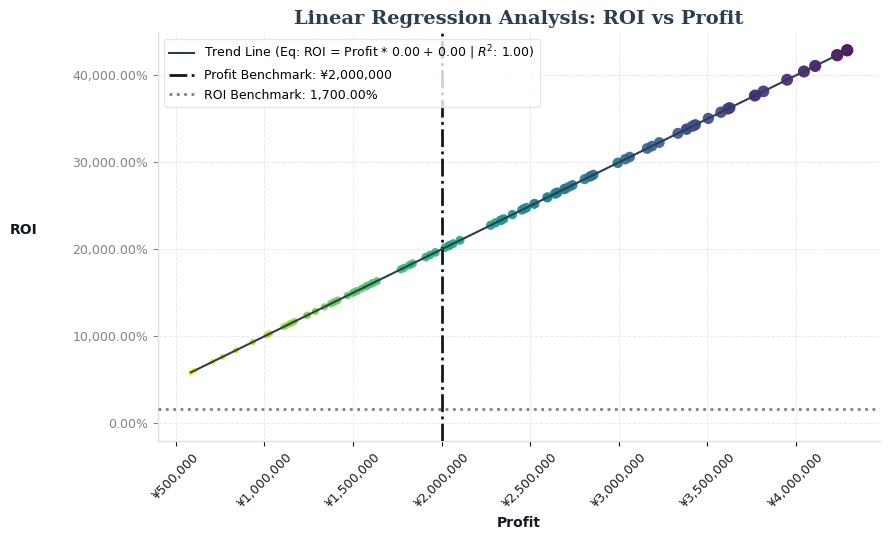

In [6]:
fig = generate_linear_regression_from_lists(simulated_x_distribution, simulated_y_distribution,
                                            variable_names.PROFIT, variable_names.ROI,
                                           x_benchmark=2000000, y_benchmark=17)
plt.show()

In [7]:
variables_2 = {variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
               variable_names.DEAL_SELLING_PRICE: selling_price,
               variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
               variable_names.DEAL_ITEMS_PER_ORDER: items_per_order,
               variable_names.COST_ADVERTISING: advertising_budget,
               variable_names.COST_CPA: cpa,
               variable_names.COST_CONVERSION_RATE: conversion_rate,
               variable_names.EXPENSE: expense,
              variable_names.COST_SETUP: setup_cost}

simulated_x_distribution, simulated_y_distribution, linear_trend_summary = stochastic_bivariate_simulation(
    variables=variables_2,
    independent_target_x=variable_names.COST_ADVERTISING,
    dependent_target_y=variable_names.NET_INCOME,
    shuffled_variables=[
        variable_names.COST_ADVERTISING,
        variable_names.DEAL_SELLING_PRICE,
        variable_names.DEAL_ITEMS_PER_ORDER],
    model_pipeline=[advertising_efficiency_model, cogs_model, revenue_model, cost_model,
                    depreciation_model, capital_expenditure_model,
                    net_income_model, profit_model, roi_model],
    sample_size=100)

print(linear_trend_summary)

{'slope': 66.72430175640801, 'intercept': 53734.76295587048, 'r_squared': 0.2539121095034723, 'p_value': 9.070565576354963e-08, 'standard_error': 11.5537851869677}


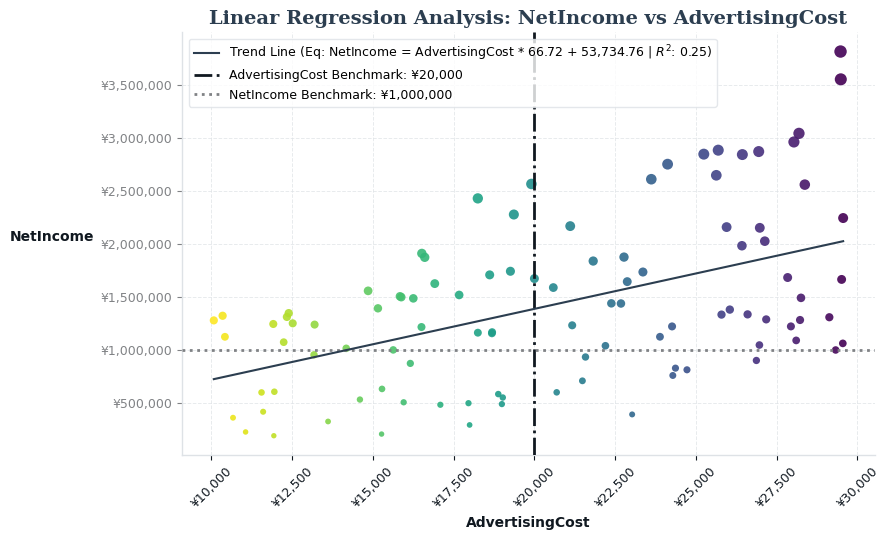

In [8]:
fig = generate_linear_regression_from_lists(simulated_x_distribution, simulated_y_distribution,
                                            variable_names.COST_ADVERTISING, variable_names.NET_INCOME,
                                            x_benchmark=20000, y_benchmark=1000000)
plt.show()

## Scenario 2

In [9]:
from src.models import CostOfGoodsSoldModel, TotalCostModel, RevenueModel, TotalExpenseModel, DepreciationModel, \
    CapitalExpenditureModel, NetIncomeModel, ProfitModel, AdvertisingEfficiencyGoogleSearchModel, \
    CostPerLeadGoogleSearchModel, RoasModel, OrderModel
from src.variables import GoogleSearchCostPerClick, AdvertisingBudget, GoogleSearchAllocationPercentage, \
    GoogleSearchConversionRate, CloseRate, ItemsPerOrder, SellingPrice, PurchasingPrice, USDToRMB

In [10]:
budget = AdvertisingBudget(3000, 2000, 5000)
google_search_allocation = GoogleSearchAllocationPercentage(0.6, 0.5, 0.7)
cpc = GoogleSearchCostPerClick(2.5, 1.8, 3.5)
cvr = GoogleSearchConversionRate(0.04, 0.02, 0.06)
close_rate = CloseRate(0.12, 0.08, 0.18)

items_per_order = ItemsPerOrder(2, 1.5, 3)
# selling_price = SellingPrice(8000, 5000, 10000)
selling_price = SellingPrice(3000, 2000, 4000)
purchasing_price = PurchasingPrice(2000, 1100, 2500)

usd_to_rmb = USDToRMB(6.8, 6.0, 7.5)

variables = {
    variable_names.COST_ADVERTISING: budget,
    variable_names.ALLOCATION_GOOGLE_SEARCH: google_search_allocation,
    variable_names.CPC_GOOGLE_SEARCH: cpc,
    variable_names.CONVERSION_RATE_GOOGLE_SEARCH: cvr,
    variable_names.CLOSE_RATE: close_rate,
    variable_names.DEAL_SELLING_PRICE: selling_price,
    variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
    variable_names.DEAL_ITEMS_PER_ORDER: items_per_order,
    variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
}

cogs_model = CostOfGoodsSoldModel()
cost_model = TotalCostModel()
revenue_model = RevenueModel()
expense_model = TotalExpenseModel()
depreciation_model = DepreciationModel()
capital_expenditure_model = CapitalExpenditureModel()
net_income_model = NetIncomeModel()
profit_model = ProfitModel()
order_model = OrderModel()

advertising_efficiency_google_search_model = AdvertisingEfficiencyGoogleSearchModel()
cost_per_lead_model = CostPerLeadGoogleSearchModel()
roas_model = RoasModel()

model_pipeline = [advertising_efficiency_google_search_model, order_model,
                  cogs_model, cost_model, revenue_model, net_income_model, profit_model, cost_per_lead_model, roas_model]

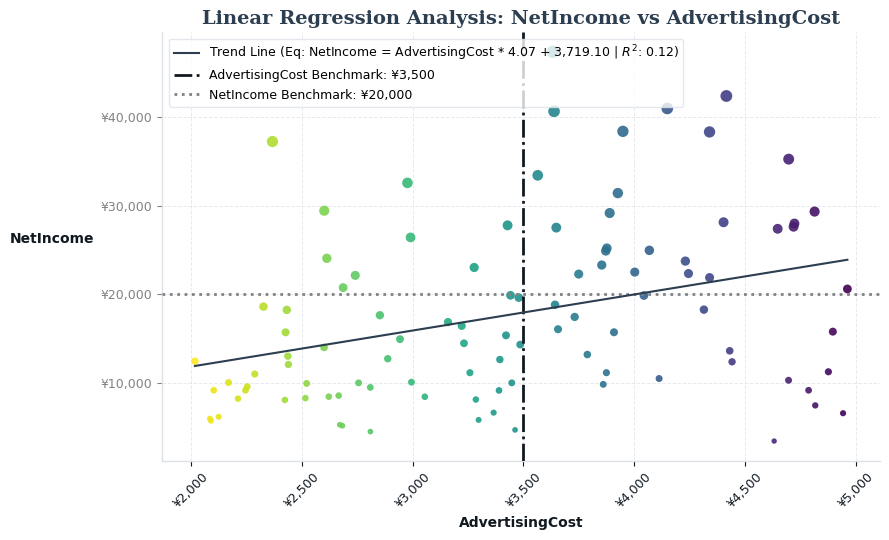

In [11]:
simulated_x_distribution, simulated_y_distribution, linear_trend_summary = stochastic_bivariate_simulation(
    variables=variables,
    independent_target_x=variable_names.COST_ADVERTISING,
    dependent_target_y=variable_names.NET_INCOME,
    shuffled_variables=[variable_names.COST_ADVERTISING,
                        variable_names.CPC_GOOGLE_SEARCH,
                        variable_names.CONVERSION_RATE_GOOGLE_SEARCH,
                        variable_names.CLOSE_RATE, 
                        variable_names.DEAL_SELLING_PRICE],
    model_pipeline=model_pipeline,
    sample_size=100)

fig = generate_linear_regression_from_lists(simulated_x_distribution, simulated_y_distribution,
                                            variable_names.COST_ADVERTISING, variable_names.NET_INCOME,
                                            x_benchmark=3500, y_benchmark=20000)
                                           
plt.show()

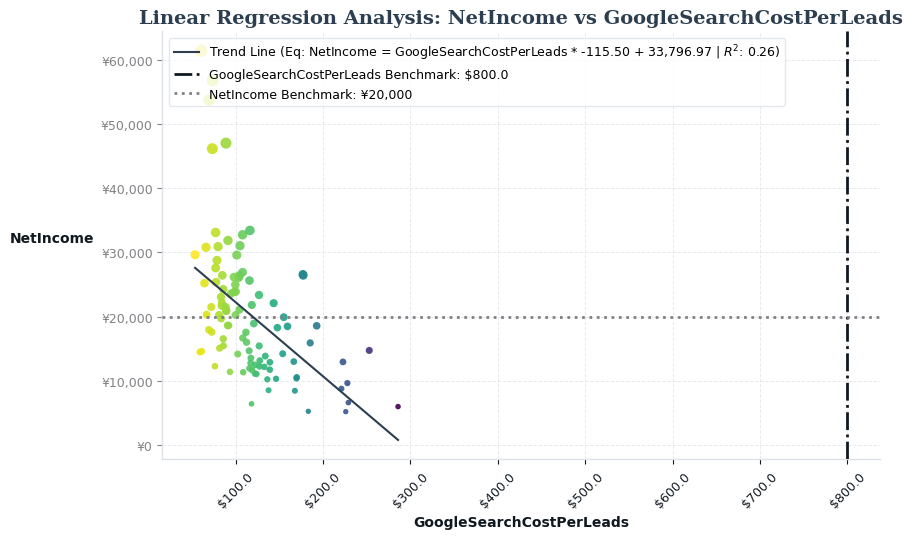

In [12]:
simulated_x_distribution, simulated_y_distribution, linear_trend_summary = stochastic_bivariate_simulation(
    variables=variables,
    independent_target_x=variable_names.CPL_GOOGLE_SEARCH,
    dependent_target_y=variable_names.NET_INCOME,
    shuffled_variables=[variable_names.COST_ADVERTISING,
                        variable_names.CPC_GOOGLE_SEARCH,
                        variable_names.CONVERSION_RATE_GOOGLE_SEARCH,
                        variable_names.CLOSE_RATE, 
                        variable_names.DEAL_SELLING_PRICE],
    model_pipeline=model_pipeline,
    sample_size=100)

fig = generate_linear_regression_from_lists(simulated_x_distribution, simulated_y_distribution,
                                            variable_names.CPL_GOOGLE_SEARCH, variable_names.NET_INCOME,
                                            x_benchmark=800, y_benchmark=20000)
                                           
plt.show()

the impact of cpl is more significant than that of ads budget on net income. Compared with ads budget where `$1` more increment on ads can bring `$7.61` net income, optimizing ads strategy by `$1` less on cpl can bring `$21.67` on net income